In [63]:
import torch
from monai.networks.nets import SwinUNETR

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

model = SwinUNETR(
    in_channels=3,
    out_channels=2,
    feature_size=12,
    use_checkpoint=False
).to(device)

model.load_state_dict(
    torch.load("/Users/apple/Desktop/BRAINIAC/models/best_swin_unetr.pt",
               map_location=device)
)

model.eval()
print("✅ Model loaded")

✅ Model loaded


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

feature_maps = {}

def save_features(name):
    def hook(model, input, output):
        feature_maps[name] = output.detach().cpu()
    return hook

model.swinViT.layers4.register_forward_hook(save_features("encoder_output"))

In [ ]:
import nibabel as nib
import numpy as np
import torch
import glob, os

def load_brats_case(case_folder, modalities=("t1ce","t2","flair")):
    vols = []
    for mod in modalities:
        f = glob.glob(os.path.join(case_folder, f"*_{mod}.nii*"))
        if len(f) == 0:
            raise ValueError(f"Missing modality {mod} in {case_folder}")

        nii = nib.load(f[0])
        vol = nii.get_fdata().astype(np.float32)

        vol = (vol - vol.min()) / (vol.max() - vol.min() + 1e-6)
        vols.append(vol)

    vols = np.stack(vols, axis=0)  
    vols = vols[None]              

    return torch.tensor(vols, dtype=torch.float32)

In [ ]:
CASE_FOLDER = "/Users/apple/Desktop/BRAINIAC/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_369"

x_original = load_brats_case(CASE_FOLDER)

_,_,D,H,W = x_original.shape
size=128
z=(D-size)//2; y=(H-size)//2; x0=(W-size)//2
x_original = x_original[:,:,z:z+size,y:y+size,x0:x0+size]
x_original = x_original.to(device)

print("Loaded new case:", x_original.shape)

Loaded new case: torch.Size([1, 3, 128, 128, 128])


In [ ]:


import torch, nibabel as nib, numpy as np, glob, os
from monai.networks.nets import SwinUNETR

MODEL_PATH = "/Users/apple/Desktop/BRAINIAC/models/best_swin_unetr.pt"
CASE_FOLDER = "/Users/apple/Desktop/BRAINIAC/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_369"

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

model = SwinUNETR(
    in_channels=3,
    out_channels=2,
    feature_size=12,
    use_checkpoint=False
).to(device)

model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()
print("✅ Model loaded")

def load_brats_case(case_folder, modalities=("t1ce","t2","flair")):
    vols = []
    for mod in modalities:
        f = glob.glob(os.path.join(case_folder, f"*_{mod}.nii*"))
        if len(f) == 0:
            raise ValueError(f"Missing modality {mod}")
        vol = nib.load(f[0]).get_fdata().astype(np.float32)
        vol = (vol - vol.min())/(vol.max()-vol.min()+1e-6)
        vols.append(vol)
    vols = np.stack(vols, axis=0)   
    vols = vols[None]               
    return torch.tensor(vols, dtype=torch.float32)

x_original = load_brats_case(CASE_FOLDER)

_,_,D,H,W = x_original.shape
size = 128
z=(D-size)//2; y=(H-size)//2; x0=(W-size)//2
x_original = x_original[:,:,z:z+size,y:y+size,x0:x0+size]
x_original = x_original.to(device)

print("Input shape:", x_original.shape)


x_cf = x_original.clone()

feature_maps = {}

def save_features(name):
    def hook(module, input, output):
        feature_maps[name] = output.detach()
    return hook

handle = model.swinViT.layers4[0].register_forward_hook(
    save_features("encoder_output")
)

with torch.no_grad():
    _ = model(x_original)
    fm_original = feature_maps["encoder_output"]

    _ = model(x_cf)
    fm_cf = feature_maps["encoder_output"]

handle.remove()

print("✅ Features extracted")
print("Original feature shape:", fm_original.shape)
print("CF feature shape:", fm_cf.shape)

diff = torch.mean(torch.abs(fm_original - fm_cf)).item()
print("Feature shift score:", diff)

✅ Model loaded
Input shape: torch.Size([1, 3, 128, 128, 128])
✅ Features extracted
Original feature shape: torch.Size([1, 192, 4, 4, 4])
CF feature shape: torch.Size([1, 192, 4, 4, 4])
Feature shift score: 0.0


In [68]:
feature_diff = np.abs(heat_original - heat_cf)

In [ ]:
import numpy as np

assert "heat_original" in globals(), "heat_original missing"
assert "heat_cf" in globals(), "heat_cf missing"

feature_diff = np.abs(heat_original - heat_cf)

print("✅ feature_diff ready:", feature_diff.shape)

✅ feature_diff ready: (128, 128, 128)


In [ ]:
import torch.nn.functional as F


heat_original = torch.mean(fm_original, dim=1, keepdim=True)
heat_cf       = torch.mean(fm_cf, dim=1, keepdim=True)

heat_original = F.interpolate(
    heat_original,
    size=(128,128,128),
    mode="trilinear",
    align_corners=False
).squeeze().cpu().numpy()

heat_cf = F.interpolate(
    heat_cf,
    size=(128,128,128),
    mode="trilinear",
    align_corners=False
).squeeze().cpu().numpy()

print("✅ Heatmaps ready")
print("Shape:", heat_original.shape)

✅ Heatmaps ready
Shape: (128, 128, 128)


In [ ]:
import torch.nn.functional as F


heat_original = torch.mean(fm_original, dim=1, keepdim=True)
heat_cf       = torch.mean(fm_cf, dim=1, keepdim=True)

heat_original = F.interpolate(
    heat_original,
    size=(128,128,128),
    mode="trilinear",
    align_corners=False
).squeeze().cpu().numpy()

heat_cf = F.interpolate(
    heat_cf,
    size=(128,128,128),
    mode="trilinear",
    align_corners=False
).squeeze().cpu().numpy()

print("✅ Heatmaps ready")
print("Shape:", heat_original.shape)

✅ Heatmaps ready
Shape: (128, 128, 128)


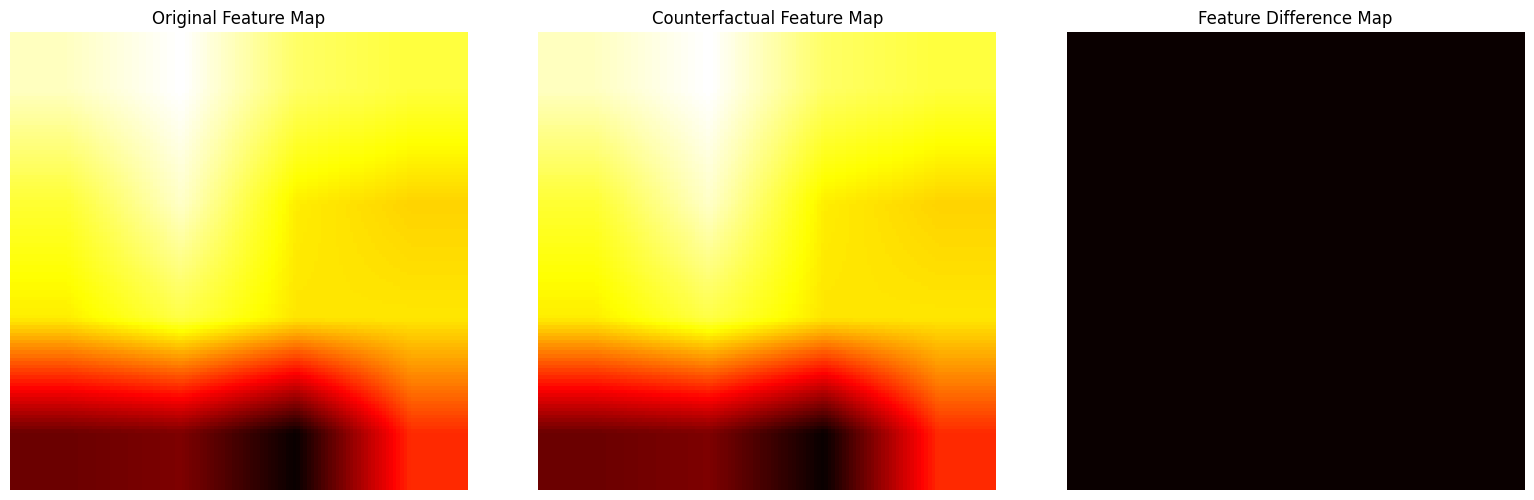

In [72]:
slice_id = heat_original.shape[0] // 2

plt.figure(figsize=(16,5))

plt.subplot(1,3,1)
plt.title("Original Feature Map")
plt.imshow(heat_original[slice_id], cmap="hot")
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Counterfactual Feature Map")
plt.imshow(heat_cf[slice_id], cmap="hot")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Feature Difference Map")
plt.imshow(feature_diff[slice_id], cmap="hot")
plt.axis("off")

plt.tight_layout()
plt.show()